In [14]:
import os
import sys
import datetime
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.font_manager import FontProperties
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase, HandlerTuple
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from scipy.spatial import cKDTree

sys.path.insert(0, '/home/users/zhiyi/PROJECTS_ANALYSIS')
from zhiyi.analysis.SE_analysis import get_site_index
from zhiyi.plot.Plot_2D import Plot_2D

os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
print('done')


done


In [15]:
BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')

SCRIP_NE30 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc'
SCRIP_NE60 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc'

FILEBASE_NE30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
FILEBASE_NE60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/'
                 'MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc')

MAP_START = datetime.date(2018, 5, 22)
MAP_END = datetime.date(2018, 6, 14)
TS_START = datetime.date(2018, 5, 22)
TS_END = datetime.date(2018, 6, 15)
PLOT_START = pd.to_datetime('2018-05-22')
PLOT_END = pd.to_datetime('2018-06-14')
SHADE_START = pd.to_datetime('2018-05-27')
SHADE_END = pd.to_datetime('2018-06-02')

CITY_LONLAT = {
    'London': [360 - 0.213492, 51.521050],
    'Manchester': [360 - 2.237881, 53.481520],
    'Glasgow': [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
}
CITIES = list(CITY_LONLAT.keys())

PM25_OBS_FILES = {
    'London': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/london_pm2.5.csv',
    'Manchester': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/manchester_pm2.5.csv',
    'Glasgow': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/glasgow_pm2.5.csv',
    'Birmingham': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/birmingham_pm2.5.csv',
}

O3_OBS_FILES = {
    'London': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/london_o3.csv',
    'Manchester': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/manchester_o3.csv',
    'Glasgow': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/glasgow_o3.csv',
    'Birmingham': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/birmingham_o3.csv',
}

O3_OBS_SCALE = {
    'London': 0.5033,
    'Manchester': 0.5007,
    'Glasgow': 0.4976,
    'Birmingham': 0.5005,
}


In [16]:
class HandlerBoxPlot(HandlerBase):
    def __init__(self, sx=1.0, sy=1.8, lw=2.0,
                 box_h_frac=0.75, box_w_frac=0.55,
                 whisk_out_frac=0.35, cap_hfrac=0.30, **kwargs):
        super().__init__(**kwargs)
        self.sx, self.sy = sx, sy
        self.lw = lw
        self.box_h_frac = box_h_frac
        self.box_w_frac = box_w_frac
        self.whisk_out_frac = whisk_out_frac
        self.cap_hfrac = cap_hfrac

    def create_artists(self, legend, orig_handle, x0, y0, w, h, fontsize, trans):
        sx, sy = self.sx, self.sy
        lw = self.lw
        bhf = self.box_h_frac
        bwf = self.box_w_frac
        wf = self.whisk_out_frac
        chf = self.cap_hfrac

        xc, yc = x0 + w / 2, y0 + h / 2
        w, h = w * sx, h * sy
        x0, y0 = xc - w / 2, yc - h / 2

        box_w = w * bwf
        box_x = x0 + (w - box_w) / 2
        box_h = h * bhf
        box_y = y0 + (h - box_h) / 2
        whisk = box_w * wf
        y_mid = y0 + h / 2

        box = Rectangle((box_x, box_y), box_w, box_h, fill=False, edgecolor='k', lw=lw, transform=trans)
        med = Line2D([box_x + box_w / 2, box_x + box_w / 2], [box_y, box_y + box_h],
                     color='orange', lw=lw, transform=trans)
        wl = Line2D([box_x - whisk, box_x], [y_mid, y_mid], color='k', lw=lw, transform=trans)
        wr = Line2D([box_x + box_w, box_x + box_w + whisk], [y_mid, y_mid], color='k', lw=lw, transform=trans)
        capl = Line2D([box_x - whisk, box_x - whisk], [y_mid - chf * h / 2, y_mid + chf * h / 2],
                      color='k', lw=lw, transform=trans)
        capr = Line2D([box_x + box_w + whisk, box_x + box_w + whisk],
                      [y_mid - chf * h / 2, y_mid + chf * h / 2], color='k', lw=lw, transform=trans)
        return [wl, wr, capl, capr, box, med]


def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = template.replace('MM', cur.strftime('%m')).replace('DD', cur.strftime('%d'))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f'Warning: File not found - {f}, skipping.')
        cur += datetime.timedelta(days=1)
    return files


def _date_columns(df):
    return [
        c for c in df.columns
        if isinstance(c, str) and not pd.isna(pd.to_datetime(c, format='%Y-%m-%d', errors='coerce'))
    ]


def _selected_date_columns(df):
    date_cols = _date_columns(df)
    dates = pd.to_datetime(date_cols, format='%Y-%m-%d')
    mask = (dates >= pd.to_datetime(MAP_START)) & (dates <= pd.to_datetime(MAP_END))
    return [date_cols[i] for i, ok in enumerate(mask) if ok]


def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180


def get_neighborhood_minmax(ds, species, tree, city_lon, city_lat, k):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx = tree.query([city_lat, lon180_c], k=k)
    values = ds[species][:, -1, idx].values * 1e9
    return np.nanmin(values, axis=1), np.nanmax(values, axis=1)


def to_bst_naive(values):
    return (pd.to_datetime(values.astype('datetime64[ns]'))
            .tz_localize('UTC')
            .tz_convert('Europe/London')
            .tz_localize(None))


def load_hourly_obs(path, scale=1.0):
    obs = pd.read_csv(path)
    obs['Date'] = pd.to_datetime(obs['Date'].astype(str) + ' ' + obs['Time'].astype(str), errors='coerce')
    obs['average'] = pd.to_numeric(obs['average'], errors='coerce') * scale
    obs = obs[(obs['Date'] >= PLOT_START) & (obs['Date'] <= PLOT_END)].sort_values('Date')
    return obs[['Date', 'average']]


In [17]:
se_files_30 = collect_files(FILEBASE_NE30, TS_START, TS_END)
se_files_60 = collect_files(FILEBASE_NE60, TS_START, TS_END)

ds_ne30 = xr.open_mfdataset(se_files_30, combine='by_coords')
ds_ne60 = xr.open_mfdataset(se_files_60, combine='by_coords')

average_data_BB = ds_ne30.sel(time=slice('2018-05-22', '2018-06-14 23:59:59')).mean(dim='time')
average_data_ne60BB = ds_ne60.sel(time=slice('2018-05-22', '2018-06-14 23:59:59')).mean(dim='time')

scrip30 = xr.open_dataset(SCRIP_NE30)
scrip60 = xr.open_dataset(SCRIP_NE60)

print('Datasets loaded!')


Datasets loaded!


In [18]:
def _plot_distribution(row_axes, plot_settings, latobs, lonobs, color_arr, letters, pollutant_title):
    for i, (scrip, data, title, vmin, vmax, unit) in enumerate(plot_settings):
        ax = row_axes.flat[i]
        p = Plot_2D(
            data,
            scrip_file=scrip, pretty_tick=True,
            lon_range=[-9.5, 2.5], lat_range=[49.5, 60.5],
            lon_interval=MAP_LON_INTERVAL, lat_interval=MAP_LAT_INTERVAL,
            resolution='10m', country=True, state=True, title=title,
            title_bold=True, unit=unit, nticks=6, title_size=20,
            label_size=MAP_Y_MAJOR_LABEL_SIZE, cmax=vmax, cmin=vmin,
            grid_line_lw=0.15, lonlat_line=False,
            shrink=0.54, pad=0.08, unit_offset=[0.05, 0], ax=ax,
        )
        p.im.set_rasterized(True)

        ax.xaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
        ax.tick_params(
            axis='x', which='major', labelsize=MAP_X_MAJOR_LABEL_SIZE,
            pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )
        ax.tick_params(
            axis='x', which='minor', labelsize=MAP_X_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
            length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )

        if i == 0:
            ax.yaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
            ax.tick_params(
                axis='y', which='major', labelsize=MAP_Y_MAJOR_LABEL_SIZE,
                pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
            ax.tick_params(
                axis='y', which='minor', labelsize=MAP_Y_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
                length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
        if i == 1:
            ax.set_ylabel('', fontsize=18, labelpad=25)
            ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

        cmap = plt.colormaps['jet']
        for lon, lat, color_value in zip(lonobs, latobs, color_arr):
            ax.plot(
                lon, lat, linestyle='none', marker='o', markersize=10,
                c=cmap(color_value), markeredgecolor='black', markeredgewidth=0.5,
                transform=ccrs.PlateCarree(),
            )

        ax.set_xlabel('', fontsize=18)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=20)
        ax.text(
            0.036, 0.96, letters[i], transform=ax.transAxes,
            fontsize=30, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5', alpha=1),
        )
        ax.text(
            0.002, 1, pollutant_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='left', weight='bold', zorder=10,
        )
        grid_title = r'ne60' if i == 0 else r'ne30$\times$16'
        grid_x = 0.885 if i == 0 else 0.785
        ax.text(grid_x, 1, grid_title, transform=ax.transAxes,
                fontsize=30, va='bottom', ha='left', weight='bold', zorder=10)


pm25_data_ne60BB = average_data_ne60BB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB = average_data_BB['PM25'].isel(lev=-1) * 1e9

df_pm25 = pd.read_csv(
    '/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv',
    skiprows=1,
)
latobs_pm25 = df_pm25['Latitude'].values
lonobs_pm25 = df_pm25['Longitude'].values + 360
selected_cols_pm25 = _selected_date_columns(df_pm25)
valobs_pm25 = df_pm25[selected_cols_pm25].mean(axis=1).values
color_arr_pm25 = valobs_pm25 / 24
color_arr_pm25[color_arr_pm25 > 1] = 1

plot_settings_pm25 = [
    (SCRIP_NE60, pm25_data_ne60BB, '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
    (SCRIP_NE30, pm25_data_BB, '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
]

o3_data_ne60BB = average_data_ne60BB['O3'].isel(lev=-1) * 1e9
o3_data_BB = average_data_BB['O3'].isel(lev=-1) * 1e9

df_o3 = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/O3_zs.csv')
latobs_o3 = df_o3['Latitude'].values
lonobs_o3 = df_o3['Longitude'].values + 360
selected_cols_o3 = _selected_date_columns(df_o3)
obs_num_o3 = df_o3[selected_cols_o3].apply(pd.to_numeric, errors='coerce')
valobs_o3 = (obs_num_o3 * 0.498).mean(axis=1).to_numpy()
color_arr_o3 = valobs_o3 / 65
color_arr_o3[color_arr_o3 > 1] = 1

plot_settings_o3 = [
    (SCRIP_NE60, o3_data_ne60BB, '', 0, 65, 'O$_{3}$ (ppbv)'),
    (SCRIP_NE30, o3_data_BB, '', 0, 65, 'O$_{3}$ (ppbv)'),
]


In [19]:
Index_lonlat_30 = {}
Index_lonlat_60 = {}
for city, (lon360_c, lat_c) in CITY_LONLAT.items():
    Index_lonlat_30[city] = get_site_index(lon360_c, lat_c, scrip_file=SCRIP_NE30)
    Index_lonlat_60[city] = get_site_index(lon360_c, lat_c, scrip_file=SCRIP_NE60)

tree_30, lon360_30, lat_30, lon180_30 = build_kdtree(ds_ne30)
tree_60, lon360_60, lat_60, lon180_60 = build_kdtree(ds_ne60)

time_values_bst = {
    'ne30': to_bst_naive(pd.to_datetime(ds_ne30.time.values).values),
    'ne60': to_bst_naive(pd.to_datetime(ds_ne60.time.values).values),
}


def prepare_species_timeseries(species):
    species_data = {
        'ne30': {}, 'ne60': {},
        'min30': {}, 'max30': {}, 'min60': {}, 'max60': {},
        'obs': {},
    }
    for city, (lon_c, lat_c) in CITY_LONLAT.items():
        idx30 = Index_lonlat_30[city]
        idx60 = Index_lonlat_60[city]
        species_data['ne30'][city] = ds_ne30[species].values[:, -1, idx30] * 1e9
        species_data['ne60'][city] = ds_ne60[species].values[:, -1, idx60] * 1e9

        mn30, mx30 = get_neighborhood_minmax(ds_ne30, species, tree_30, lon_c, lat_c, k=36)
        mn60, mx60 = get_neighborhood_minmax(ds_ne60, species, tree_60, lon_c, lat_c, k=2)
        species_data['min30'][city], species_data['max30'][city] = mn30, mx30
        species_data['min60'][city], species_data['max60'][city] = mn60, mx60
    return species_data


pm25_ts = prepare_species_timeseries('PM25')
o3_ts = prepare_species_timeseries('O3')

for city in CITIES:
    pm25_ts['obs'][city] = load_hourly_obs(PM25_OBS_FILES[city], scale=1.0)
    o3_ts['obs'][city] = load_hourly_obs(O3_OBS_FILES[city], scale=O3_OBS_SCALE[city])


def draw_timeseries_group(axes, species_data, letter, ylabel, ylim, major_step):
    day_locator = mdates.DayLocator(interval=1)
    day_formatter = mdates.DateFormatter('%m-%d')

    for i, city in enumerate(CITIES):
        ax = axes[i]
        ax.fill_between(time_values_bst['ne30'], species_data['min30'][city], species_data['max30'][city],
                        alpha=0.4, color='salmon')
        ax.plot(time_values_bst['ne30'], species_data['ne30'][city].squeeze(),
                color='coral', linewidth=2.5, label='ne30x16')
        ax.fill_between(time_values_bst['ne60'], species_data['min60'][city], species_data['max60'][city],
                        alpha=0.4, color='cornflowerblue')
        ax.plot(time_values_bst['ne60'], species_data['ne60'][city].squeeze(),
                color='royalblue', linewidth=2.5, label='ne60')

        obs = species_data['obs'][city]
        ax.plot(obs['Date'], obs['average'], color='black', linewidth=2.5, alpha=0.9, label='AURN Obs')
        ax.axvspan(SHADE_START, SHADE_END, color='green', alpha=0.15, zorder=0)

        ax.set_title(city, fontsize=30, fontweight='bold')
        ax.xaxis.set_major_locator(day_locator)
        ax.xaxis.set_major_formatter(day_formatter)
        ax.set_xlim(PLOT_START, PLOT_END)
        ax.set_ylim(*ylim)
        ax.set_ylabel(ylabel, fontsize=20)
        ax.yaxis.set_major_locator(MultipleLocator(major_step))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=9, length=8, width=1)
        ax.tick_params(axis='y', which='minor', labelsize=18 * 0.8, length=4, width=1)

        if i < len(CITIES) - 1:
            ax.tick_params(axis='x', which='both', labelbottom=False)
            ax.set_xticks([])
        else:
            plt.setp(ax.get_xticklabels(), rotation=0, fontsize=22)
            ax.set_xlabel('Date', fontsize=20)
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
            ax.xaxis.set_minor_locator(AutoMinorLocator(2))
            ax.tick_params(axis='x', which='major', labelsize=30, pad=9, length=8, width=1)
            ax.tick_params(axis='x', which='minor', labelsize=18 * 0.8, length=4, width=1)

        if i == 0:
            ax.legend(
                fontsize=25,
                loc='lower right',
                bbox_to_anchor=(1.01, 0.85),
                ncol=3,
                columnspacing=0.8,
                handlelength=1.4,
                handletextpad=0.4,
                frameon=False,
            )


Text(0.5708211382113821, 0.287025876410305, 'O$_{3}$ (ppbv)')

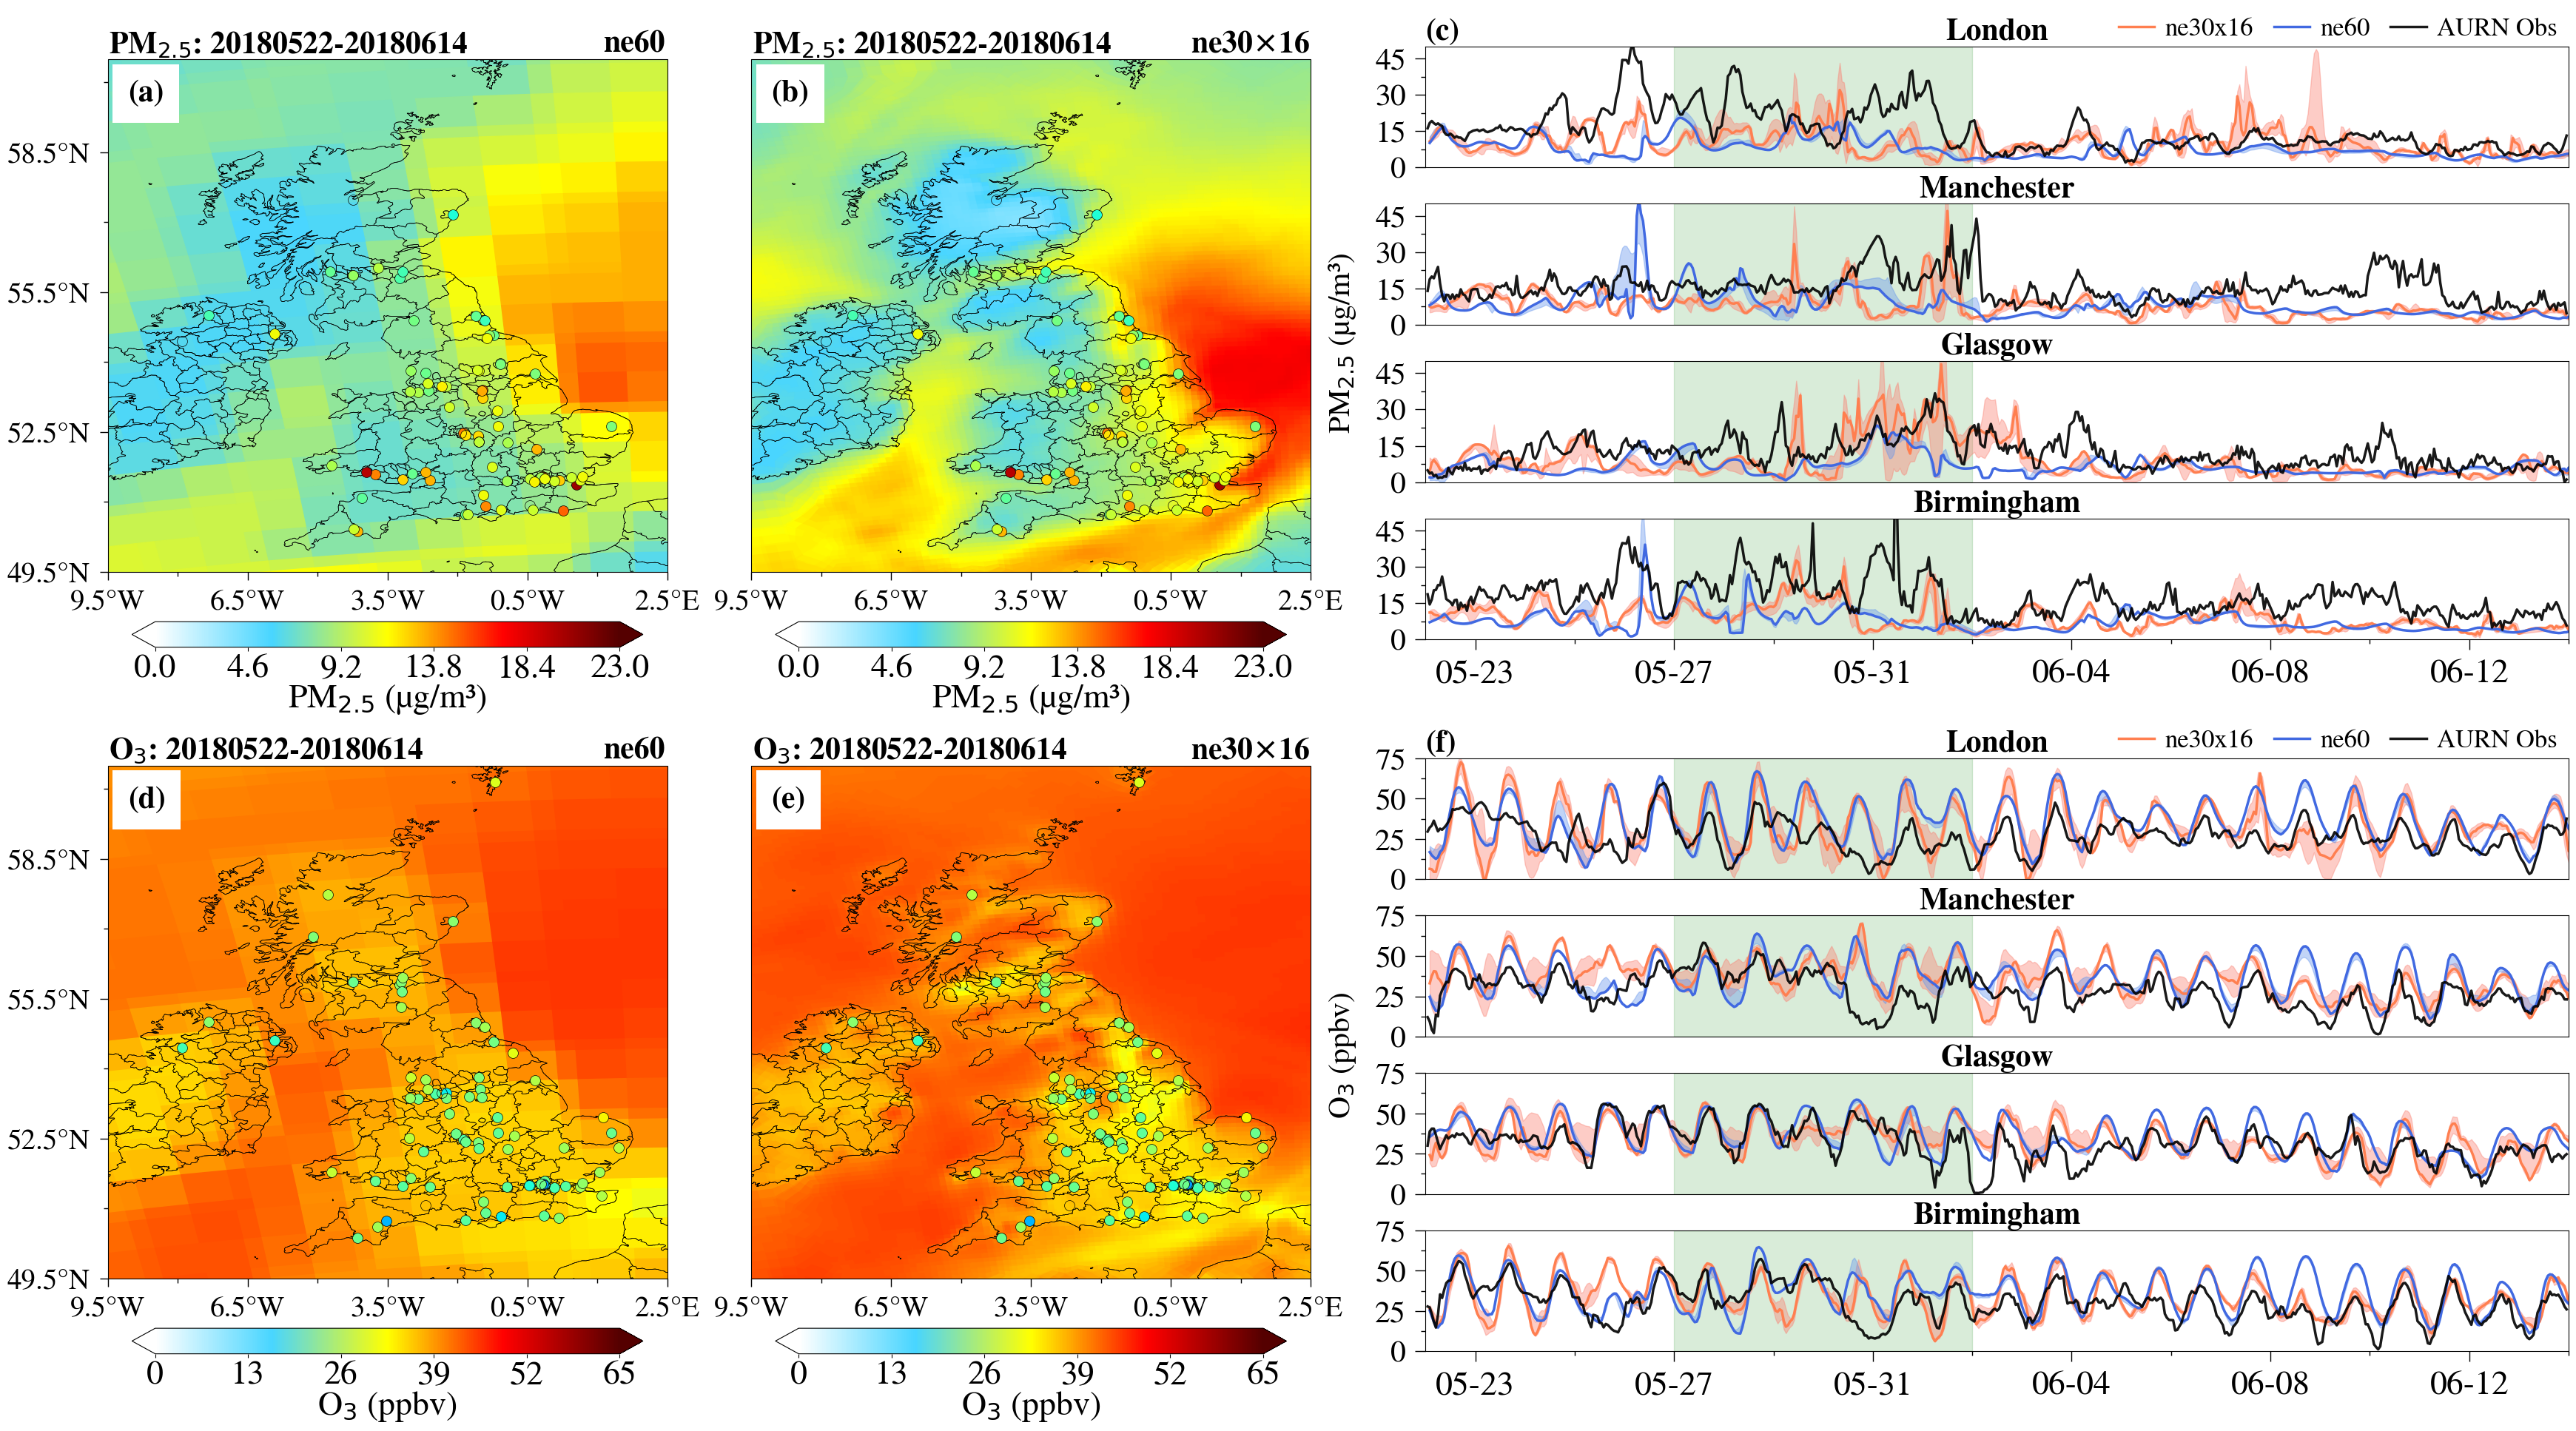

In [21]:
MAP_LON_INTERVAL = 3
MAP_LAT_INTERVAL = 3
MAP_MINOR_TICKS = 2
MAP_X_MAJOR_LABEL_SIZE = 28
MAP_Y_MAJOR_LABEL_SIZE = 28
MAP_MINOR_LABEL_SCALE = 0.8
MAP_MAJOR_TICK_PAD = 9
MAP_MAJOR_TICK_LENGTH = 8
MAP_MINOR_TICK_LENGTH = 4
MAP_TICK_WIDTH = 1

fig = plt.figure(figsize=(40, 20))

outer_gs = fig.add_gridspec(
    1, 2,
    width_ratios=[25, 15],
    left=0.035, right=0.985, bottom=0.06, top=0.96,
    wspace=-0.155,
)

map_gs = outer_gs[0, 0].subgridspec(2, 2, wspace=-0.49, hspace=0.13)
map_axes = np.empty((2, 2), dtype=object)
map_axes[0, 0] = fig.add_subplot(map_gs[0, 0], projection=ccrs.PlateCarree())
map_axes[0, 1] = fig.add_subplot(map_gs[0, 1], projection=ccrs.PlateCarree())
map_axes[1, 0] = fig.add_subplot(map_gs[1, 0], projection=ccrs.PlateCarree())
map_axes[1, 1] = fig.add_subplot(map_gs[1, 1], projection=ccrs.PlateCarree())

right_gs = outer_gs[0, 1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.2)
pm25_ts_gs = right_gs[0, 0].subgridspec(4, 1, hspace=0.3)
o3_ts_gs = right_gs[1, 0].subgridspec(4, 1, hspace=0.3)
pm25_axes = [fig.add_subplot(pm25_ts_gs[i, 0]) for i in range(4)]
o3_axes = [fig.add_subplot(o3_ts_gs[i, 0]) for i in range(4)]


def _plot_distribution(row_axes, plot_settings, latobs, lonobs, color_arr, letters, pollutant_title):
    for i, (scrip, data, title, vmin, vmax, unit) in enumerate(plot_settings):
        ax = row_axes.flat[i]
        p = Plot_2D(
            data,
            scrip_file=scrip, pretty_tick=True,
            lon_range=[-9.5, 2.5], lat_range=[49.5, 60.5],
            lon_interval=MAP_LON_INTERVAL, lat_interval=MAP_LAT_INTERVAL,
            resolution='10m', country=True, state=True, title=title,
            title_bold=True, unit=unit, nticks=6, title_size=20,
            label_size=MAP_Y_MAJOR_LABEL_SIZE, cmax=vmax, cmin=vmin,
            grid_line_lw=0.15, lonlat_line=False,
            shrink=0.54, pad=0.08, unit_offset=[0.05, 0], ax=ax,
        )
        p.im.set_rasterized(True)

        ax.xaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
        ax.tick_params(
            axis='x', which='major', labelsize=MAP_X_MAJOR_LABEL_SIZE,
            pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )
        ax.tick_params(
            axis='x', which='minor', labelsize=MAP_X_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
            length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )

        if i == 0:
            ax.yaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
            ax.tick_params(
                axis='y', which='major', labelsize=MAP_Y_MAJOR_LABEL_SIZE,
                pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
            ax.tick_params(
                axis='y', which='minor', labelsize=MAP_Y_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
                length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
        if i == 1:
            ax.set_ylabel('', fontsize=18, labelpad=25)
            ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

        cmap = plt.colormaps['jet']
        for lon, lat, color_value in zip(lonobs, latobs, color_arr):
            ax.plot(
                lon, lat, linestyle='none', marker='o', markersize=10,
                c=cmap(color_value), markeredgecolor='black', markeredgewidth=0.5,
                transform=ccrs.PlateCarree(),
            )

        ax.set_xlabel('', fontsize=18)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=20)
        ax.text(
            0.036, 0.96, letters[i], transform=ax.transAxes,
            fontsize=30, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5', alpha=1),
        )
        ax.text(
            0.002, 1, pollutant_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='left', weight='bold', zorder=10,
        )
        grid_title = r'ne60' if i == 0 else r'ne30$\times$16'
        grid_x = 0.885 if i == 0 else 0.785
        ax.text(grid_x, 1, grid_title, transform=ax.transAxes,
                fontsize=30, va='bottom', ha='left', weight='bold', zorder=10)

_plot_distribution(
    map_axes[0, :], plot_settings_pm25,
    latobs_pm25, lonobs_pm25, color_arr_pm25,
    ['(a)', '(b)'],
    'PM$_{2.5}$: 20180522-20180614',
)

_plot_distribution(
    map_axes[1, :], plot_settings_o3,
    latobs_o3, lonobs_o3, color_arr_o3,
    ['(d)', '(e)'],
    'O$_{3}$: 20180522-20180614',
)


TS_C_X_DAY_INTERVAL = 4
TS_C_Y_MAJOR_INTERVAL = 15
TS_C_X_MAJOR_LABEL_SIZE = 33
TS_C_Y_MAJOR_LABEL_SIZE = 30
TS_C_MINOR_LABEL_SCALE = 0.8
TS_C_MAJOR_TICK_PAD = 9
TS_C_MAJOR_TICK_LENGTH = 10
TS_C_MINOR_TICK_LENGTH = 4
TS_C_TICK_WIDTH = 1

TS_F_X_DAY_INTERVAL = 4
TS_F_Y_MAJOR_INTERVAL = 25
TS_F_X_MAJOR_LABEL_SIZE = 33
TS_F_Y_MAJOR_LABEL_SIZE = 30
TS_F_MINOR_LABEL_SCALE = 0.8
TS_F_MAJOR_TICK_PAD = 9
TS_F_MAJOR_TICK_LENGTH = 10
TS_F_MINOR_TICK_LENGTH = 4
TS_F_TICK_WIDTH = 1

draw_timeseries_group(
    pm25_axes, pm25_ts, '(c)', 'PM$_{2.5}$ (µg/m³)', (0, 50), TS_C_Y_MAJOR_INTERVAL
)
draw_timeseries_group(
    o3_axes, o3_ts, '(f)', 'O$_{3}$ (ppbv)', (0, 75), TS_F_Y_MAJOR_INTERVAL
)


def _apply_timeseries_tick_style(
    axes, x_day_interval, y_major_interval,
    x_major_label_size, y_major_label_size, minor_label_scale,
    major_tick_pad, major_tick_length, minor_tick_length, tick_width,
):
    for ax in axes:
        ax.yaxis.set_major_locator(MultipleLocator(y_major_interval))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(
            axis='y', which='major', labelsize=y_major_label_size,
            pad=major_tick_pad, length=major_tick_length, width=tick_width,
        )
        ax.tick_params(
            axis='y', which='minor', labelsize=y_major_label_size * minor_label_scale,
            length=minor_tick_length, width=tick_width,
        )

    for ax in axes[:-1]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])

    bottom_ax = axes[-1]
    bottom_ax.xaxis.set_major_locator(mdates.DayLocator(interval=x_day_interval))
    bottom_ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    bottom_ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    bottom_ax.tick_params(
        axis='x', which='major', labelsize=x_major_label_size,
        pad=major_tick_pad, length=major_tick_length, width=tick_width,
    )
    bottom_ax.tick_params(
        axis='x', which='minor', labelsize=x_major_label_size * minor_label_scale,
        length=minor_tick_length, width=tick_width,
    )


_apply_timeseries_tick_style(
    pm25_axes,
    TS_C_X_DAY_INTERVAL, TS_C_Y_MAJOR_INTERVAL,
    TS_C_X_MAJOR_LABEL_SIZE, TS_C_Y_MAJOR_LABEL_SIZE, TS_C_MINOR_LABEL_SCALE,
    TS_C_MAJOR_TICK_PAD, TS_C_MAJOR_TICK_LENGTH, TS_C_MINOR_TICK_LENGTH, TS_C_TICK_WIDTH,
)
_apply_timeseries_tick_style(
    o3_axes,
    TS_F_X_DAY_INTERVAL, TS_F_Y_MAJOR_INTERVAL,
    TS_F_X_MAJOR_LABEL_SIZE, TS_F_Y_MAJOR_LABEL_SIZE, TS_F_MINOR_LABEL_SCALE,
    TS_F_MAJOR_TICK_PAD, TS_F_MAJOR_TICK_LENGTH, TS_F_MINOR_TICK_LENGTH, TS_F_TICK_WIDTH,
)

CBAR_LENGTH_SCALE = 0.75
CBAR_THICKNESS_SCALE = 1.00
CBAR_X_OFFSET = 0.00
CBAR_Y_OFFSET = 0.00
CBAR_TICK_SIZE = 33
CBAR_UNIT_SIZE = 33

cbar_axes = [
    ax for ax in fig.axes
    if ax not in map_axes.flat and ax not in pm25_axes and ax not in o3_axes
]
for cbar_ax in cbar_axes:
    pos = cbar_ax.get_position()
    new_width = pos.width * CBAR_LENGTH_SCALE
    new_height = pos.height * CBAR_THICKNESS_SCALE
    new_x0 = pos.x0 + (pos.width - new_width) / 2 + CBAR_X_OFFSET
    new_y0 = pos.y0 + (pos.height - new_height) / 2 + CBAR_Y_OFFSET
    cbar_ax.set_position([new_x0, new_y0, new_width, new_height])
    cbar_ax.tick_params(labelsize=CBAR_TICK_SIZE)
    for txt in cbar_ax.texts:
        txt.set_position((0.5, -1.4))
        txt.set_ha('center')
        txt.set_va('top')
        txt.set_fontstyle('normal')
        txt.set_fontsize(CBAR_UNIT_SIZE)

TS_SHARED_Y_LABEL_SIZE = 30
TS_SHARED_Y_LABEL_X_OFFSET = 0.028
TS_PM25_SHARED_Y_LABEL = 'PM$_{2.5}$ (µg/m³)'
TS_O3_SHARED_Y_LABEL = 'O$_{3}$ (ppbv)'
TS_PANEL_LETTER_SIZE = 30
TS_PANEL_LETTER_X_OFFSET = 0.000
TS_PANEL_LETTER_Y_OFFSET = 0.0

for ax in [*pm25_axes, *o3_axes]:
    ax.set_ylabel('')
    ax.yaxis.label.set_visible(False)
    ax.set_xlabel('')
    ax.xaxis.label.set_visible(False)


def _panel_tight_bbox(fig, axes):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bboxes = [
        ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
        for ax in axes
        if ax.get_visible() and ax.get_tightbbox(renderer) is not None
    ]
    return matplotlib.transforms.Bbox.union(bboxes)


def _match_panel_height(fig, target_axes, moving_axes, n_iter=3):
    for _ in range(n_iter):
        target_bbox = _panel_tight_bbox(fig, target_axes)
        moving_bbox = _panel_tight_bbox(fig, moving_axes)
        target_height = target_bbox.y1 - target_bbox.y0
        moving_height = moving_bbox.y1 - moving_bbox.y0
        if moving_height <= 0:
            return
        scale = target_height / moving_height
        for ax in moving_axes:
            pos = ax.get_position()
            new_y0 = target_bbox.y0 + (pos.y0 - moving_bbox.y0) * scale
            new_y1 = target_bbox.y0 + (pos.y1 - moving_bbox.y0) * scale
            ax.set_position([pos.x0, new_y0, pos.width, new_y1 - new_y0])


_match_panel_height(
    fig,
    target_axes=[*map_axes.flat, *cbar_axes],
    moving_axes=[*pm25_axes, *o3_axes],
)


def _axes_position_bbox(axes):
    return matplotlib.transforms.Bbox.union([ax.get_position() for ax in axes])


TS_GROUP_Y_OFFSET = 0.015

for ax in [*pm25_axes, *o3_axes]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 + TS_GROUP_Y_OFFSET, pos.width, pos.height])



pm25_bbox = _axes_position_bbox(pm25_axes)
o3_bbox = _axes_position_bbox(o3_axes)
fig.text(
    pm25_bbox.x0 + TS_PANEL_LETTER_X_OFFSET,
    pm25_bbox.y1 + TS_PANEL_LETTER_Y_OFFSET,
    '(c)',
    va='bottom', ha='left', weight='bold', fontsize=TS_PANEL_LETTER_SIZE,
)
fig.text(
    o3_bbox.x0 + TS_PANEL_LETTER_X_OFFSET,
    o3_bbox.y1 + TS_PANEL_LETTER_Y_OFFSET,
    '(f)',
    va='bottom', ha='left', weight='bold', fontsize=TS_PANEL_LETTER_SIZE,
)
fig.text(
    pm25_bbox.x0 - TS_SHARED_Y_LABEL_X_OFFSET,
    (pm25_bbox.y0 + pm25_bbox.y1) / 2,
    TS_PM25_SHARED_Y_LABEL,
    rotation='vertical', va='center', ha='center', fontsize=TS_SHARED_Y_LABEL_SIZE,
)
fig.text(
    o3_bbox.x0 - TS_SHARED_Y_LABEL_X_OFFSET,
    (o3_bbox.y0 + o3_bbox.y1) / 2,
    TS_O3_SHARED_Y_LABEL,
    rotation='vertical', va='center', ha='center', fontsize=TS_SHARED_Y_LABEL_SIZE,
)







In [ ]:
figure_data_dir = BASE_DIR / 'figure_data'
figure_data_dir.mkdir(parents=True, exist_ok=True)
figure3_path = figure_data_dir / 'Figure4.nc'


def _surface_values(data_array):
    return np.asarray(data_array.values).reshape(-1)


def _grid_coord(ds, name):
    values = ds[name]
    if 'time' in values.dims:
        values = values.isel(time=0)
    return np.asarray(values.values).reshape(-1)


def _stack_city_time(species_data, key):
    return np.vstack([np.asarray(species_data[key][city]).reshape(-1) for city in CITIES])


Figure3 = xr.Dataset(
    data_vars={
        'pm25_map_ne60': (('ncol_ne60',), _surface_values(pm25_data_ne60BB)),
        'pm25_map_ne30': (('ncol_ne30',), _surface_values(pm25_data_BB)),
        'o3_map_ne60': (('ncol_ne60',), _surface_values(o3_data_ne60BB)),
        'o3_map_ne30': (('ncol_ne30',), _surface_values(o3_data_BB)),
        'lon_ne60': (('ncol_ne60',), _grid_coord(ds_ne60, 'lon')),
        'lat_ne60': (('ncol_ne60',), _grid_coord(ds_ne60, 'lat')),
        'lon_ne30': (('ncol_ne30',), _grid_coord(ds_ne30, 'lon')),
        'lat_ne30': (('ncol_ne30',), _grid_coord(ds_ne30, 'lat')),
        'city_lon360': (('city',), np.asarray([CITY_LONLAT[city][0] for city in CITIES], dtype=float)),
        'city_lat': (('city',), np.asarray([CITY_LONLAT[city][1] for city in CITIES], dtype=float)),
        'pm25_ts_ne30': (('city', 'time_ne30'), _stack_city_time(pm25_ts, 'ne30')),
        'pm25_ts_ne60': (('city', 'time_ne60'), _stack_city_time(pm25_ts, 'ne60')),
        'pm25_min_ne30': (('city', 'time_ne30'), _stack_city_time(pm25_ts, 'min30')),
        'pm25_max_ne30': (('city', 'time_ne30'), _stack_city_time(pm25_ts, 'max30')),
        'pm25_min_ne60': (('city', 'time_ne60'), _stack_city_time(pm25_ts, 'min60')),
        'pm25_max_ne60': (('city', 'time_ne60'), _stack_city_time(pm25_ts, 'max60')),
        'o3_ts_ne30': (('city', 'time_ne30'), _stack_city_time(o3_ts, 'ne30')),
        'o3_ts_ne60': (('city', 'time_ne60'), _stack_city_time(o3_ts, 'ne60')),
        'o3_min_ne30': (('city', 'time_ne30'), _stack_city_time(o3_ts, 'min30')),
        'o3_max_ne30': (('city', 'time_ne30'), _stack_city_time(o3_ts, 'max30')),
        'o3_min_ne60': (('city', 'time_ne60'), _stack_city_time(o3_ts, 'min60')),
        'o3_max_ne60': (('city', 'time_ne60'), _stack_city_time(o3_ts, 'max60')),
        'pm25_obs_map_lon': (('pm25_obs_site',), np.asarray(lonobs_pm25, dtype=float)),
        'pm25_obs_map_lat': (('pm25_obs_site',), np.asarray(latobs_pm25, dtype=float)),
        'pm25_obs_map_color': (('pm25_obs_site',), np.asarray(color_arr_pm25, dtype=float)),
        'o3_obs_map_lon': (('o3_obs_site',), np.asarray(lonobs_o3, dtype=float)),
        'o3_obs_map_lat': (('o3_obs_site',), np.asarray(latobs_o3, dtype=float)),
        'o3_obs_map_color': (('o3_obs_site',), np.asarray(color_arr_o3, dtype=float)),
    },
    coords={
        'city': CITIES,
        'time_ne30': np.asarray(time_values_bst['ne30'], dtype='datetime64[ns]'),
        'time_ne60': np.asarray(time_values_bst['ne60'], dtype='datetime64[ns]'),
    },
)

for species_data, prefix in [(pm25_ts, 'pm25'), (o3_ts, 'o3')]:
    for city in CITIES:
        obs = species_data['obs'][city]
        obs_name = city.lower()
        obs_dim = f'{prefix}_obs_time_{obs_name}'
        Figure3[f'{prefix}_obs_{obs_name}_time'] = (
            (obs_dim,), np.asarray(obs['Date'], dtype='datetime64[ns]')
        )
        Figure3[f'{prefix}_obs_{obs_name}'] = (
            (obs_dim,), np.asarray(obs['average'], dtype=float)
        )

Figure3.attrs.clear()
for variable in Figure3.variables.values():
    variable.attrs.clear()

Figure3.to_netcdf(figure3_path)


In [24]:
figure3_path = BASE_DIR / 'figure_data' / 'Figure3.nc'
Figure3_saved = xr.open_dataset(figure3_path)
saved_cities = [str(city) for city in Figure3_saved['city'].values]

saved_time_values = {
    'ne30': pd.to_datetime(Figure3_saved['time_ne30'].values),
    'ne60': pd.to_datetime(Figure3_saved['time_ne60'].values),
}

saved_plot_settings_pm25 = [
    (SCRIP_NE60, Figure3_saved['pm25_map_ne60'], '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
    (SCRIP_NE30, Figure3_saved['pm25_map_ne30'], '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
]

saved_plot_settings_o3 = [
    (SCRIP_NE60, Figure3_saved['o3_map_ne60'], '', 0, 65, 'O$_{3}$ (ppbv)'),
    (SCRIP_NE30, Figure3_saved['o3_map_ne30'], '', 0, 65, 'O$_{3}$ (ppbv)'),
]


def _saved_city_series(var_name, city):
    return Figure3_saved[var_name].sel(city=city).values


def _saved_city_obs(prefix, city):
    obs_name = city.lower()
    return pd.DataFrame({
        'Date': pd.to_datetime(Figure3_saved[f'{prefix}_obs_{obs_name}_time'].values),
        'average': Figure3_saved[f'{prefix}_obs_{obs_name}'].values,
    })


def _build_saved_species_data(prefix):
    return {
        'ne30': {city: _saved_city_series(f'{prefix}_ts_ne30', city) for city in saved_cities},
        'ne60': {city: _saved_city_series(f'{prefix}_ts_ne60', city) for city in saved_cities},
        'min30': {city: _saved_city_series(f'{prefix}_min_ne30', city) for city in saved_cities},
        'max30': {city: _saved_city_series(f'{prefix}_max_ne30', city) for city in saved_cities},
        'min60': {city: _saved_city_series(f'{prefix}_min_ne60', city) for city in saved_cities},
        'max60': {city: _saved_city_series(f'{prefix}_max_ne60', city) for city in saved_cities},
        'obs': {city: _saved_city_obs(prefix, city) for city in saved_cities},
    }


saved_pm25_ts = _build_saved_species_data('pm25')
saved_o3_ts = _build_saved_species_data('o3')


def draw_timeseries_group_from_saved(axes, species_data, letter, ylabel, ylim, major_step):
    day_locator = mdates.DayLocator(interval=1)
    day_formatter = mdates.DateFormatter('%m-%d')

    for i, city in enumerate(saved_cities):
        ax = axes[i]
        ax.fill_between(saved_time_values['ne30'], species_data['min30'][city], species_data['max30'][city],
                        alpha=0.4, color='salmon')
        ax.plot(saved_time_values['ne30'], species_data['ne30'][city].squeeze(),
                color='coral', linewidth=2.5, label='ne30$\\times$16')
        ax.fill_between(saved_time_values['ne60'], species_data['min60'][city], species_data['max60'][city],
                        alpha=0.4, color='cornflowerblue')
        ax.plot(saved_time_values['ne60'], species_data['ne60'][city].squeeze(),
                color='royalblue', linewidth=2.5, label='ne60')

        obs = species_data['obs'][city]
        ax.plot(obs['Date'], obs['average'], color='black', linewidth=2.5, alpha=0.9, label='AURN Obs')
        ax.axvspan(SHADE_START, SHADE_END, color='green', alpha=0.15, zorder=0)

        ax.set_title(city, fontsize=30,fontweight='bold')
        ax.xaxis.set_major_locator(day_locator)
        ax.xaxis.set_major_formatter(day_formatter)
        ax.set_xlim(PLOT_START, PLOT_END)
        ax.set_ylim(*ylim)
        ax.set_ylabel(ylabel, fontsize=20)
        ax.yaxis.set_major_locator(MultipleLocator(major_step))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=9, length=8, width=1)
        ax.tick_params(axis='y', which='minor', labelsize=18 * 0.8, length=4, width=1)

        if i < len(saved_cities) - 1:
            ax.tick_params(axis='x', which='both', labelbottom=False)
            ax.set_xticks([])
        else:
            plt.setp(ax.get_xticklabels(), rotation=0, fontsize=22)
            ax.set_xlabel('Date', fontsize=20)
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
            ax.xaxis.set_minor_locator(AutoMinorLocator(2))
            ax.tick_params(axis='x', which='major', labelsize=30, pad=9, length=8, width=1)
            ax.tick_params(axis='x', which='minor', labelsize=18 * 0.8, length=4, width=1)

        if i == 0:
            ax.legend(
                fontsize=25,
                loc='lower right',
                bbox_to_anchor=(1.01, 0.85),
                ncol=3,
                columnspacing=0.8,
                handlelength=1.4,
                handletextpad=0.4,
                frameon=False,
            )


Text(0.5708211382113821, 0.287025876410305, 'O$_{3}$ (ppbv)')

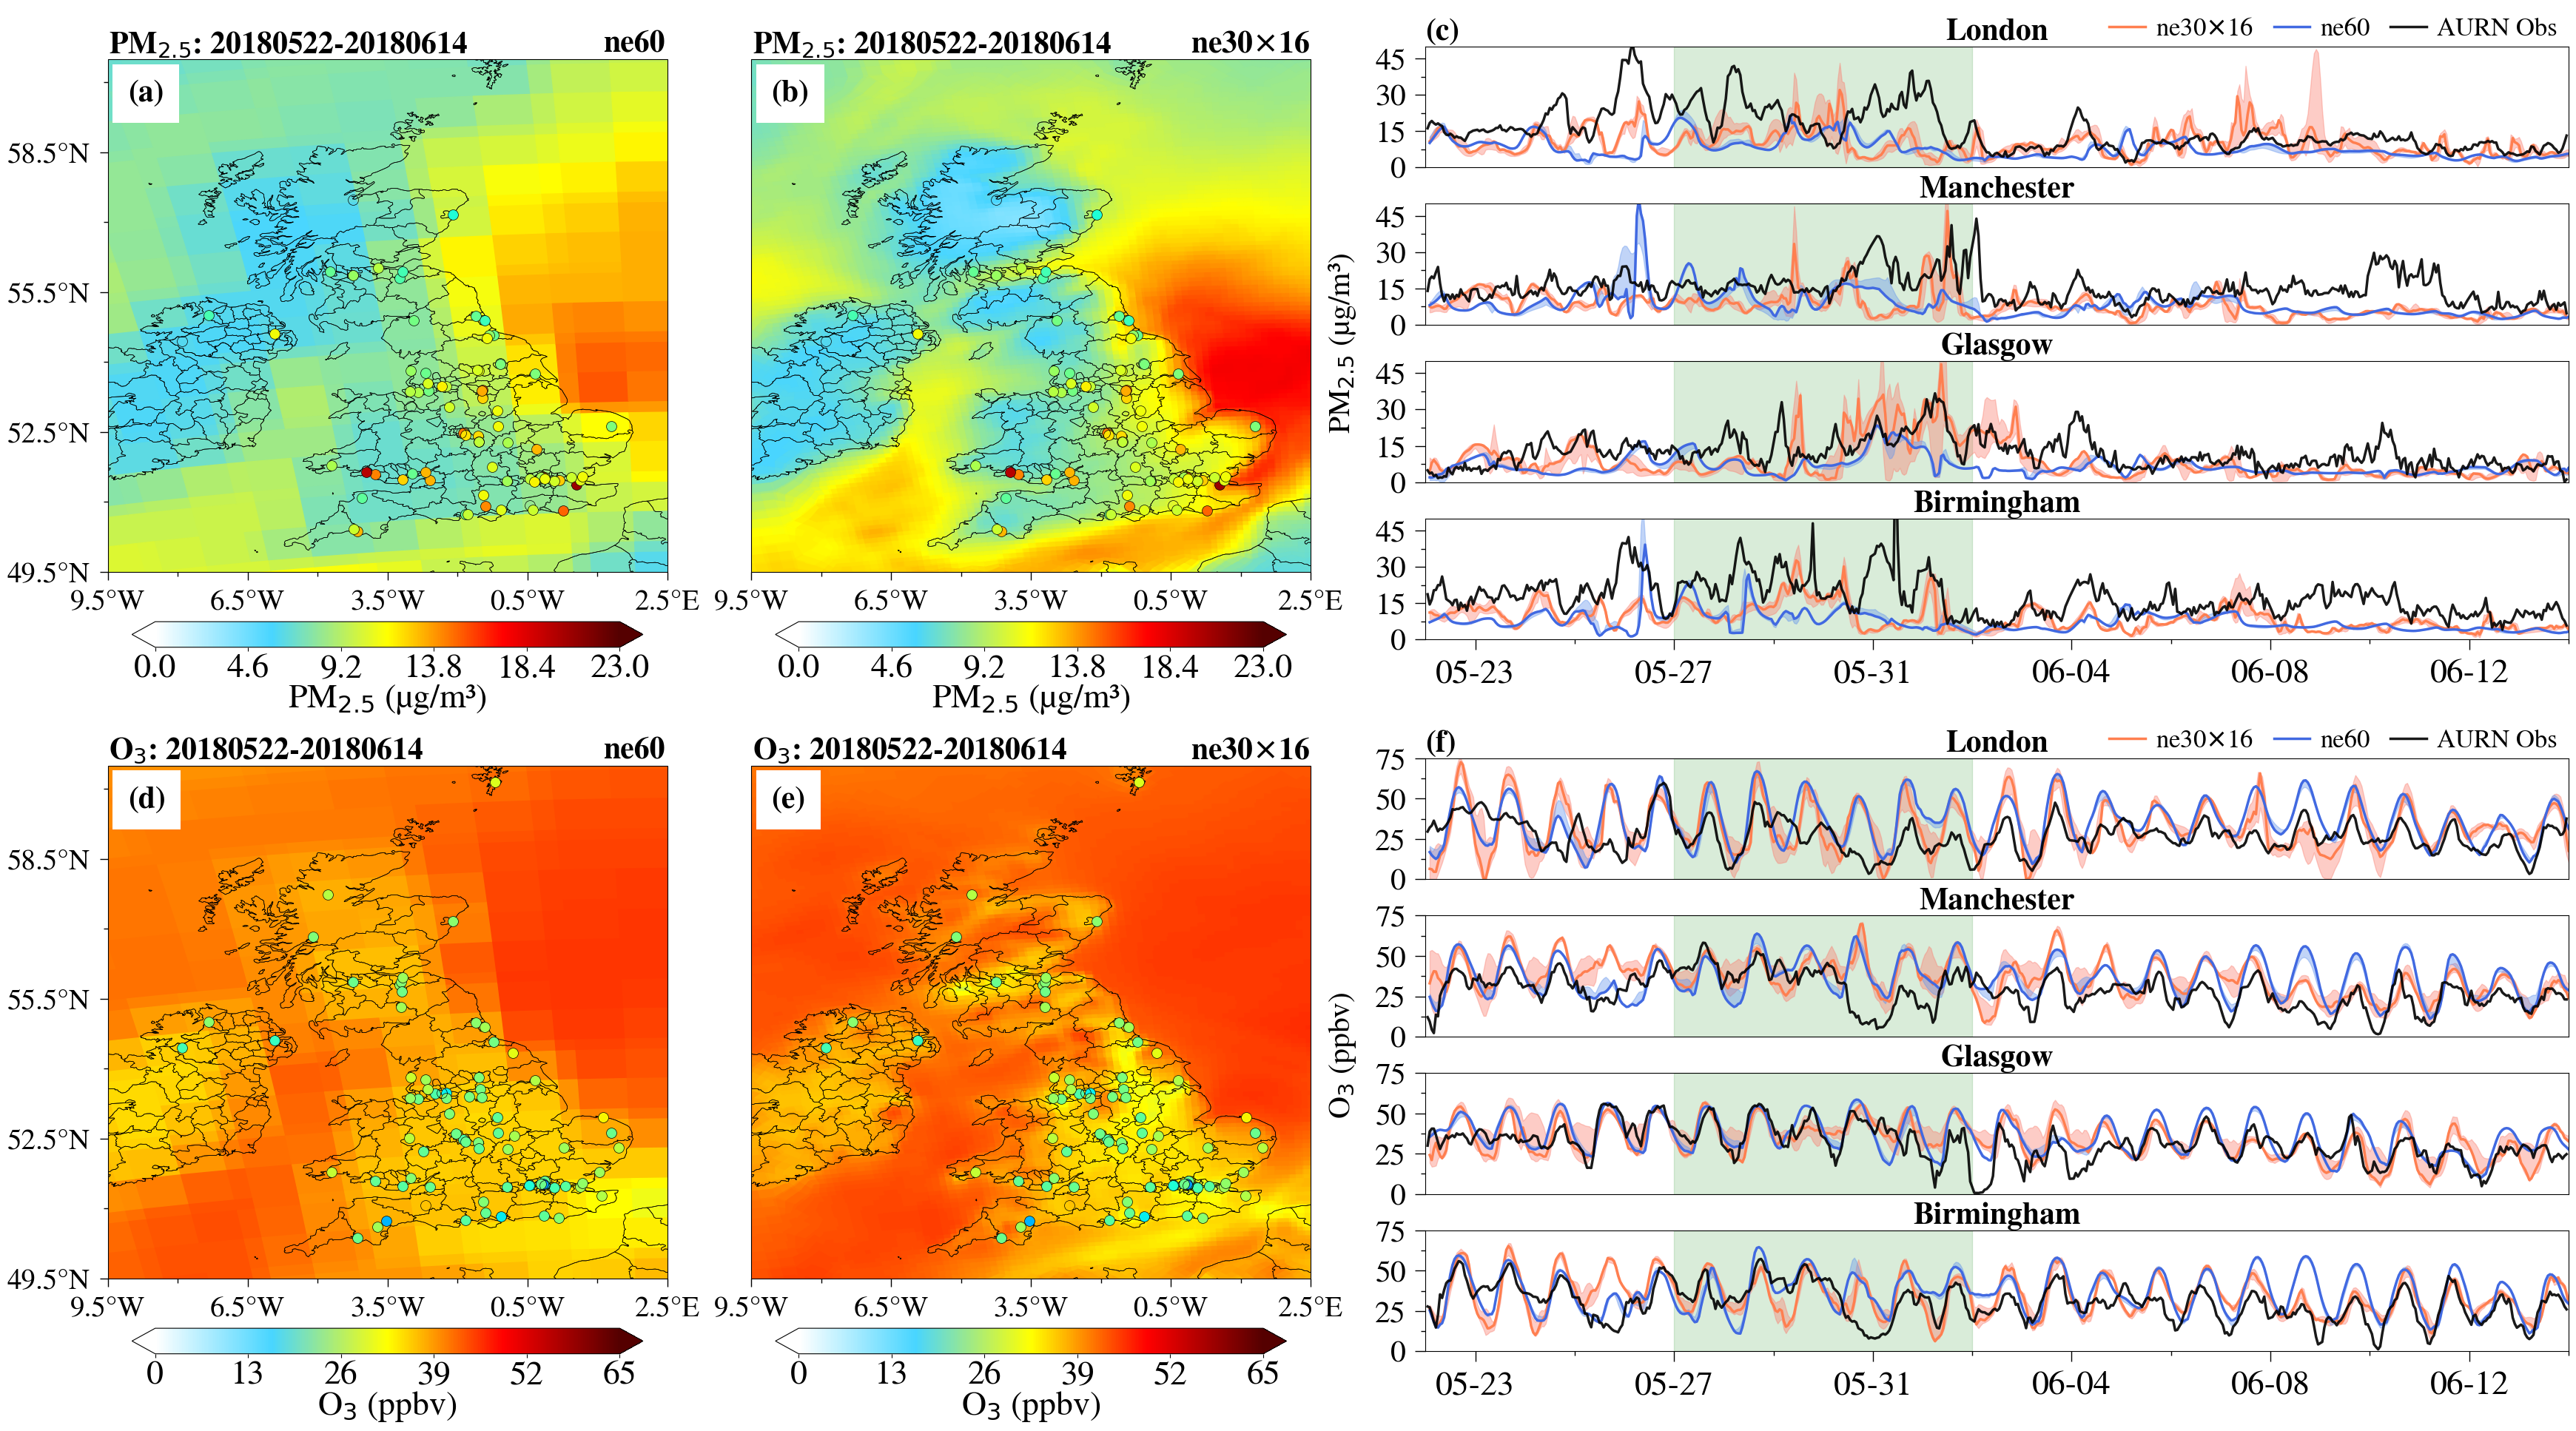

In [25]:
MAP_LON_INTERVAL = 3
MAP_LAT_INTERVAL = 3
MAP_MINOR_TICKS = 2
MAP_X_MAJOR_LABEL_SIZE = 28
MAP_Y_MAJOR_LABEL_SIZE = 28
MAP_MINOR_LABEL_SCALE = 0.8
MAP_MAJOR_TICK_PAD = 9
MAP_MAJOR_TICK_LENGTH = 8
MAP_MINOR_TICK_LENGTH = 4
MAP_TICK_WIDTH = 1
RASTERIZE_MAP_GEOGRAPHY = True

fig = plt.figure(figsize=(40, 20))

outer_gs = fig.add_gridspec(
    1, 2,
    width_ratios=[25, 15],
    left=0.035, right=0.985, bottom=0.06, top=0.96,
    wspace=-0.155,
)

map_gs = outer_gs[0, 0].subgridspec(2, 2, wspace=-0.49, hspace=0.13)
map_axes_saved = np.empty((2, 2), dtype=object)
map_axes_saved[0, 0] = fig.add_subplot(map_gs[0, 0], projection=ccrs.PlateCarree())
map_axes_saved[0, 1] = fig.add_subplot(map_gs[0, 1], projection=ccrs.PlateCarree())
map_axes_saved[1, 0] = fig.add_subplot(map_gs[1, 0], projection=ccrs.PlateCarree())
map_axes_saved[1, 1] = fig.add_subplot(map_gs[1, 1], projection=ccrs.PlateCarree())

right_gs = outer_gs[0, 1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.2)
pm25_ts_gs = right_gs[0, 0].subgridspec(4, 1, hspace=0.3)
o3_ts_gs = right_gs[1, 0].subgridspec(4, 1, hspace=0.3)
pm25_axes_saved = [fig.add_subplot(pm25_ts_gs[i, 0]) for i in range(4)]
o3_axes_saved = [fig.add_subplot(o3_ts_gs[i, 0]) for i in range(4)]


def _rasterize_cartopy_features(ax):
    for artist in ax.get_children():
        if type(artist).__module__.startswith('cartopy.mpl.feature_artist'):
            artist.set_rasterized(True)


def _plot_distribution_saved(row_axes, plot_settings, latobs, lonobs, color_arr, letters, pollutant_title):
    for i, (scrip, data, title, vmin, vmax, unit) in enumerate(plot_settings):
        ax = row_axes.flat[i]
        p = Plot_2D(
            data,
            scrip_file=scrip, pretty_tick=True,
            lon_range=[-9.5, 2.5], lat_range=[49.5, 60.5],
            lon_interval=MAP_LON_INTERVAL, lat_interval=MAP_LAT_INTERVAL,
            resolution='10m', country=True, state=True, title=title,
            title_bold=True, unit=unit, nticks=6, title_size=20,
            label_size=MAP_Y_MAJOR_LABEL_SIZE, cmax=vmax, cmin=vmin,
            grid_line_lw=0.15, lonlat_line=False,
            shrink=0.54, pad=0.08, unit_offset=[0.05, 0], ax=ax,
        )
        p.im.set_rasterized(True)
        if RASTERIZE_MAP_GEOGRAPHY:
            _rasterize_cartopy_features(ax)

        ax.xaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
        ax.tick_params(
            axis='x', which='major', labelsize=MAP_X_MAJOR_LABEL_SIZE,
            pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )
        ax.tick_params(
            axis='x', which='minor', labelsize=MAP_X_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
            length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )

        if i == 0:
            ax.yaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
            ax.tick_params(
                axis='y', which='major', labelsize=MAP_Y_MAJOR_LABEL_SIZE,
                pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
            ax.tick_params(
                axis='y', which='minor', labelsize=MAP_Y_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
                length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
        if i == 1:
            ax.set_ylabel('', fontsize=18, labelpad=25)
            ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

        cmap = plt.colormaps['jet']
        for lon, lat, color_value in zip(lonobs, latobs, color_arr):
            ax.plot(
                lon, lat, linestyle='none', marker='o', markersize=10,
                c=cmap(color_value), markeredgecolor='black', markeredgewidth=0.5,
                transform=ccrs.PlateCarree(), rasterized=True,
            )

        ax.set_xlabel('', fontsize=18)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=20)
        ax.text(
            0.036, 0.96, letters[i], transform=ax.transAxes,
            fontsize=30, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5', alpha=1),
        )
        ax.text(
            0.002, 1, pollutant_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='left', weight='bold', zorder=10,
        )
        grid_title = r'ne60' if i == 0 else r'ne30$\times$16'
        grid_x = 0.885 if i == 0 else 0.785
        ax.text(grid_x, 1, grid_title, transform=ax.transAxes,
                fontsize=30, va='bottom', ha='left', weight='bold', zorder=10)

_plot_distribution_saved(
    map_axes_saved[0, :], saved_plot_settings_pm25,
    Figure3_saved['pm25_obs_map_lat'].values,
    Figure3_saved['pm25_obs_map_lon'].values,
    Figure3_saved['pm25_obs_map_color'].values,
    ['(a)', '(b)'],
    'PM$_{2.5}$: 20180522-20180614',
)

_plot_distribution_saved(
    map_axes_saved[1, :], saved_plot_settings_o3,
    Figure3_saved['o3_obs_map_lat'].values,
    Figure3_saved['o3_obs_map_lon'].values,
    Figure3_saved['o3_obs_map_color'].values,
    ['(d)', '(e)'],
    'O$_{3}$: 20180522-20180614',
)


TS_C_X_DAY_INTERVAL = 4
TS_C_Y_MAJOR_INTERVAL = 15
TS_C_X_MAJOR_LABEL_SIZE = 33
TS_C_Y_MAJOR_LABEL_SIZE = 30
TS_C_MINOR_LABEL_SCALE = 0.8
TS_C_MAJOR_TICK_PAD = 9
TS_C_MAJOR_TICK_LENGTH = 10
TS_C_MINOR_TICK_LENGTH = 4
TS_C_TICK_WIDTH = 1

TS_F_X_DAY_INTERVAL = 4
TS_F_Y_MAJOR_INTERVAL = 25
TS_F_X_MAJOR_LABEL_SIZE = 33
TS_F_Y_MAJOR_LABEL_SIZE = 30
TS_F_MINOR_LABEL_SCALE = 0.8
TS_F_MAJOR_TICK_PAD = 9
TS_F_MAJOR_TICK_LENGTH = 10
TS_F_MINOR_TICK_LENGTH = 4
TS_F_TICK_WIDTH = 1

draw_timeseries_group_from_saved(
    pm25_axes_saved, saved_pm25_ts, '(c)', 'PM$_{2.5}$ (µg/m³)', (0, 50), TS_C_Y_MAJOR_INTERVAL
)
draw_timeseries_group_from_saved(
    o3_axes_saved, saved_o3_ts, '(f)', 'O$_{3}$ (ppbv)', (0, 75), TS_F_Y_MAJOR_INTERVAL
)


def _rasterize_timeseries_data(axes):
    for ax in axes:
        for artist in [*ax.lines, *ax.collections]:
            artist.set_rasterized(True)


_rasterize_timeseries_data([*pm25_axes_saved, *o3_axes_saved])


def _apply_timeseries_tick_style(
    axes, x_day_interval, y_major_interval,
    x_major_label_size, y_major_label_size, minor_label_scale,
    major_tick_pad, major_tick_length, minor_tick_length, tick_width,
):
    for ax in axes:
        ax.yaxis.set_major_locator(MultipleLocator(y_major_interval))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(
            axis='y', which='major', labelsize=y_major_label_size,
            pad=major_tick_pad, length=major_tick_length, width=tick_width,
        )
        ax.tick_params(
            axis='y', which='minor', labelsize=y_major_label_size * minor_label_scale,
            length=minor_tick_length, width=tick_width,
        )

    for ax in axes[:-1]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])

    bottom_ax = axes[-1]
    bottom_ax.xaxis.set_major_locator(mdates.DayLocator(interval=x_day_interval))
    bottom_ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    bottom_ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    bottom_ax.tick_params(
        axis='x', which='major', labelsize=x_major_label_size,
        pad=major_tick_pad, length=major_tick_length, width=tick_width,
    )
    bottom_ax.tick_params(
        axis='x', which='minor', labelsize=x_major_label_size * minor_label_scale,
        length=minor_tick_length, width=tick_width,
    )


_apply_timeseries_tick_style(
    pm25_axes_saved,
    TS_C_X_DAY_INTERVAL, TS_C_Y_MAJOR_INTERVAL,
    TS_C_X_MAJOR_LABEL_SIZE, TS_C_Y_MAJOR_LABEL_SIZE, TS_C_MINOR_LABEL_SCALE,
    TS_C_MAJOR_TICK_PAD, TS_C_MAJOR_TICK_LENGTH, TS_C_MINOR_TICK_LENGTH, TS_C_TICK_WIDTH,
)
_apply_timeseries_tick_style(
    o3_axes_saved,
    TS_F_X_DAY_INTERVAL, TS_F_Y_MAJOR_INTERVAL,
    TS_F_X_MAJOR_LABEL_SIZE, TS_F_Y_MAJOR_LABEL_SIZE, TS_F_MINOR_LABEL_SCALE,
    TS_F_MAJOR_TICK_PAD, TS_F_MAJOR_TICK_LENGTH, TS_F_MINOR_TICK_LENGTH, TS_F_TICK_WIDTH,
)

CBAR_LENGTH_SCALE = 0.75
CBAR_THICKNESS_SCALE = 1.00
CBAR_X_OFFSET = 0.00
CBAR_Y_OFFSET = 0.00
CBAR_TICK_SIZE = 33
CBAR_UNIT_SIZE = 33

saved_cbar_axes = [
    ax for ax in fig.axes
    if ax not in map_axes_saved.flat and ax not in pm25_axes_saved and ax not in o3_axes_saved
]
for cbar_ax in saved_cbar_axes:
    pos = cbar_ax.get_position()
    new_width = pos.width * CBAR_LENGTH_SCALE
    new_height = pos.height * CBAR_THICKNESS_SCALE
    new_x0 = pos.x0 + (pos.width - new_width) / 2 + CBAR_X_OFFSET
    new_y0 = pos.y0 + (pos.height - new_height) / 2 + CBAR_Y_OFFSET
    cbar_ax.set_position([new_x0, new_y0, new_width, new_height])
    cbar_ax.tick_params(labelsize=CBAR_TICK_SIZE)
    for txt in cbar_ax.texts:
        txt.set_position((0.5, -1.4))
        txt.set_ha('center')
        txt.set_va('top')
        txt.set_fontstyle('normal')
        txt.set_fontsize(CBAR_UNIT_SIZE)

TS_SHARED_Y_LABEL_SIZE = 30
TS_SHARED_Y_LABEL_X_OFFSET = 0.028
TS_PM25_SHARED_Y_LABEL = 'PM$_{2.5}$ (µg/m³)'
TS_O3_SHARED_Y_LABEL = 'O$_{3}$ (ppbv)'
TS_PANEL_LETTER_SIZE = 30
TS_PANEL_LETTER_X_OFFSET = 0.000
TS_PANEL_LETTER_Y_OFFSET = 0.0

for ax in [*pm25_axes_saved, *o3_axes_saved]:
    ax.set_ylabel('')
    ax.yaxis.label.set_visible(False)
    ax.set_xlabel('')
    ax.xaxis.label.set_visible(False)


def _panel_tight_bbox(fig, axes):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bboxes = [
        ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
        for ax in axes
        if ax.get_visible() and ax.get_tightbbox(renderer) is not None
    ]
    return matplotlib.transforms.Bbox.union(bboxes)


def _match_panel_height(fig, target_axes, moving_axes, n_iter=3):
    for _ in range(n_iter):
        target_bbox = _panel_tight_bbox(fig, target_axes)
        moving_bbox = _panel_tight_bbox(fig, moving_axes)
        target_height = target_bbox.y1 - target_bbox.y0
        moving_height = moving_bbox.y1 - moving_bbox.y0
        if moving_height <= 0:
            return
        scale = target_height / moving_height
        for ax in moving_axes:
            pos = ax.get_position()
            new_y0 = target_bbox.y0 + (pos.y0 - moving_bbox.y0) * scale
            new_y1 = target_bbox.y0 + (pos.y1 - moving_bbox.y0) * scale
            ax.set_position([pos.x0, new_y0, pos.width, new_y1 - new_y0])


_match_panel_height(
    fig,
    target_axes=[*map_axes_saved.flat, *saved_cbar_axes],
    moving_axes=[*pm25_axes_saved, *o3_axes_saved],
)


def _axes_position_bbox(axes):
    return matplotlib.transforms.Bbox.union([ax.get_position() for ax in axes])


TS_GROUP_Y_OFFSET = 0.015

for ax in [*pm25_axes_saved, *o3_axes_saved]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 + TS_GROUP_Y_OFFSET, pos.width, pos.height])



pm25_bbox = _axes_position_bbox(pm25_axes_saved)
o3_bbox = _axes_position_bbox(o3_axes_saved)
fig.text(
    pm25_bbox.x0 + TS_PANEL_LETTER_X_OFFSET,
    pm25_bbox.y1 + TS_PANEL_LETTER_Y_OFFSET,
    '(c)',
    va='bottom', ha='left', weight='bold', fontsize=TS_PANEL_LETTER_SIZE,
)
fig.text(
    o3_bbox.x0 + TS_PANEL_LETTER_X_OFFSET,
    o3_bbox.y1 + TS_PANEL_LETTER_Y_OFFSET,
    '(f)',
    va='bottom', ha='left', weight='bold', fontsize=TS_PANEL_LETTER_SIZE,
)
fig.text(
    pm25_bbox.x0 - TS_SHARED_Y_LABEL_X_OFFSET,
    (pm25_bbox.y0 + pm25_bbox.y1) / 2,
    TS_PM25_SHARED_Y_LABEL,
    rotation='vertical', va='center', ha='center', fontsize=TS_SHARED_Y_LABEL_SIZE,
)
fig.text(
    o3_bbox.x0 - TS_SHARED_Y_LABEL_X_OFFSET,
    (o3_bbox.y0 + o3_bbox.y1) / 2,
    TS_O3_SHARED_Y_LABEL,
    rotation='vertical', va='center', ha='center', fontsize=TS_SHARED_Y_LABEL_SIZE,
)


